# 4. Train Model (Logistic Regression)

Membuat model sendiri dari dataset yang sudah diberi label sentimen di notebook 3.

Input : `data/<keyword>_predicted.csv`
Output: `model/model_lr.joblib` (dipakai di dashboard Streamlit)

## Import library yang dibutuhkan

In [3]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

## 1. Load dataset

In [4]:
KEYWORD = "karhutla"   # <-- samakan dengan keyword saat crawling

df = pd.read_csv(f"data/{KEYWORD}_predicted.csv").dropna(subset=['full_text', 'sentiment'])
df = df[['full_text', 'sentiment']]
print("Jumlah data:", len(df))
print(df['sentiment'].value_counts())
df.head()

Jumlah data: 261
sentiment
neutral     122
positive     90
negative     49
Name: count, dtype: int64


,full_text,sentiment
0,penegakan hukum karhutla memang bergerak tetap...,negative
1,kejagung menerima spdp perkara pidana karhutla...,negative
2,polsek menjalin edukasi warga cegah karhutla s...,positive
3,karhutla di amburawang laut meluas tim gabunga...,neutral
4,di tengah kepungan api dan asap orangutan beru...,neutral


## 2. Pisahkan fitur dan label

In [5]:
X = df['full_text']   # fitur teks
y = df['sentiment']   # label sentimen

## 3. Bagi dataset + 4. buat pipeline
Data dibagi 80% latih dan 20% uji. `stratify=y` menjaga perbandingan label di data latih dan uji tetap sama.

Pipeline menggabungkan vektorisasi (TF-IDF) dan pelatihan model (Logistic Regression) dalam satu pemanggilan.

Karena data sedikit dan label neutral paling banyak, dipakai `class_weight='balanced'` supaya model tidak selalu menebak neutral.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Data latih:", len(X_train), "| Data uji:", len(X_test))

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),         # langkah 1: vektorisasi
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',   # label yang jumlahnya sedikit diberi bobot lebih besar
        C=10,                      # regularisasi lebih longgar, cocok untuk data sedikit
    )),                                                    # langkah 2: pelatihan model
])

Data latih: 208 | Data uji: 53


## 5. Latih pipeline

In [7]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['negative','neutral','positive']"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",5000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None


## 6. Hasil prediksi pada data uji
- **precision**: dari yang ditebak label X, berapa persen yang benar
- **recall**: dari yang sebenarnya label X, berapa persen yang berhasil ditebak
- **accuracy**: persentase tebakan benar secara keseluruhan

In [8]:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

    negative       0.71      0.50      0.59        10
     neutral       0.61      0.88      0.72        25
    positive       0.70      0.39      0.50        18

    accuracy                           0.64        53
   macro avg       0.68      0.59      0.60        53
weighted avg       0.66      0.64      0.62        53



## (Tambahan) Confusion matrix
Menunjukkan label mana yang sering tertukar.

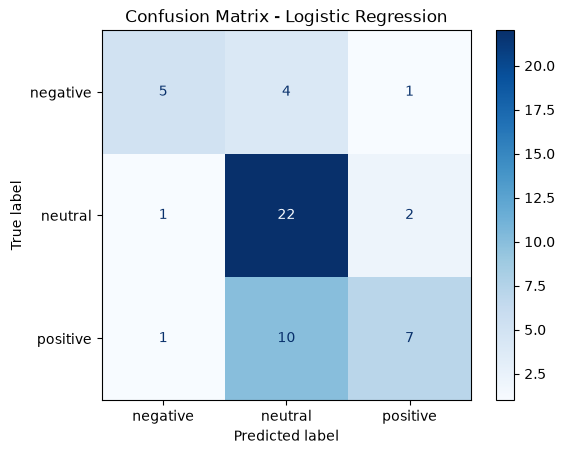

In [9]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

## (Tambahan) Coba prediksi kalimat baru

In [10]:
for kal in ["kesel banget pemerintah ga peduli asap",
            "terima kasih petugas pemadam sudah bekerja keras",
            "bnpb merilis jumlah titik panas hari ini"]:
    print(f"{kal!r:55} -> {pipeline.predict([kal])[0]}")

'kesel banget pemerintah ga peduli asap'                -> negative
'terima kasih petugas pemadam sudah bekerja keras'      -> positive
'bnpb merilis jumlah titik panas hari ini'              -> neutral


## 7. Simpan modelnya

In [9]:
joblib.dump(pipeline, 'model/model_lr.joblib')

['model/model_lr.joblib']